# Machine Learning 

### Analisis descriptivo

#### Cargue de librerias 

In [1]:
#Cargar las librerías
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import seaborn as sns

import sweetviz as sv

#### Cargar dataset Tratado en la Fase de limpieza

In [2]:
# Cargar dataset
df = pd.read_csv('data/data_clean.csv', sep=',', encoding='utf-8',)

df.head()

,id_ano,fecha_de_notificacion_del_evento,sexo,area_de_residencia,barrio_de_residencia,seguridad_social,estrato_socioeconomico,gestante,poblacion_a_cargo_icbf,fecha_del_hecho,...,inmolacion,lanzamiento_al_vacio,lanzamiento_a_vehiculo,lanzamiento_al_agua,intoxicaciones,remitido_a_psiquiatria,remitido_a_psicologia,remitido_a_trabajo_social,edad_rango,escolaridad_grupo
0,2020,2020-01-02,FEMENINO,CABECERA MUNICIPAL,CASTILLA,CONTRIBUTIVO,3,0,0,2020-01-02,...,0,0,0,0,0,1,1,0,adulto_joven,Básica
1,2020,2020-01-03,FEMENINO,CABECERA MUNICIPAL,LA MARIA,CONTRIBUTIVO,5,0,0,2020-01-03,...,0,0,0,0,1,1,1,0,adulto_mayor,Superior
2,2020,2020-01-17,MASCULINO,CABECERA MUNICIPAL,LIBERTADOR,NO ASEGURADO,2,0,0,2020-01-09,...,0,1,0,0,0,1,1,0,adulto_mayor,Superior
3,2020,2020-01-21,MASCULINO,CABECERA MUNICIPAL,ASIS BOYACENSE,CONTRIBUTIVO,3,0,0,2020-01-21,...,0,0,0,0,1,1,1,0,joven,Básica
4,2020,2020-01-21,MASCULINO,CABECERA MUNICIPAL,REMANSOS DE LA SABANA,CONTRIBUTIVO,3,0,0,2020-01-21,...,0,0,0,0,0,1,0,0,adulto_joven,Superior


#### Creamos una copia del df

In [3]:
datos = df.copy()
datos.head()

,id_ano,fecha_de_notificacion_del_evento,sexo,area_de_residencia,barrio_de_residencia,seguridad_social,estrato_socioeconomico,gestante,poblacion_a_cargo_icbf,fecha_del_hecho,...,inmolacion,lanzamiento_al_vacio,lanzamiento_a_vehiculo,lanzamiento_al_agua,intoxicaciones,remitido_a_psiquiatria,remitido_a_psicologia,remitido_a_trabajo_social,edad_rango,escolaridad_grupo
0,2020,2020-01-02,FEMENINO,CABECERA MUNICIPAL,CASTILLA,CONTRIBUTIVO,3,0,0,2020-01-02,...,0,0,0,0,0,1,1,0,adulto_joven,Básica
1,2020,2020-01-03,FEMENINO,CABECERA MUNICIPAL,LA MARIA,CONTRIBUTIVO,5,0,0,2020-01-03,...,0,0,0,0,1,1,1,0,adulto_mayor,Superior
2,2020,2020-01-17,MASCULINO,CABECERA MUNICIPAL,LIBERTADOR,NO ASEGURADO,2,0,0,2020-01-09,...,0,1,0,0,0,1,1,0,adulto_mayor,Superior
3,2020,2020-01-21,MASCULINO,CABECERA MUNICIPAL,ASIS BOYACENSE,CONTRIBUTIVO,3,0,0,2020-01-21,...,0,0,0,0,1,1,1,0,joven,Básica
4,2020,2020-01-21,MASCULINO,CABECERA MUNICIPAL,REMANSOS DE LA SABANA,CONTRIBUTIVO,3,0,0,2020-01-21,...,0,0,0,0,0,1,0,0,adulto_joven,Superior


In [4]:
#Listando variables para entender
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 818 entries, 0 to 817
Data columns (total 47 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   id_ano                                        818 non-null    int64
 1   fecha_de_notificacion_del_evento              818 non-null    str  
 2   sexo                                          818 non-null    str  
 3   area_de_residencia                            818 non-null    str  
 4   barrio_de_residencia                          818 non-null    str  
 5   seguridad_social                              818 non-null    str  
 6   estrato_socioeconomico                        818 non-null    int64
 7   gestante                                      818 non-null    int64
 8   poblacion_a_cargo_icbf                        818 non-null    int64
 9   fecha_del_hecho                               818 non-null    str  
 10  intentos_previos         

#### Calidad de los datos

In [5]:
# Verificación de valores nulos y filas duplicadas
nulos = datos.isnull().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores nulos.")

print(f"\nFilas duplicadas: {datos.duplicated().sum()}")

Valores nulos por columna:
No hay valores nulos.

Filas duplicadas: 0


No se encontraron valores nulos ni filas duplicadas, por lo que el dataset está completo a nivel de registros.

#### Exploracion de inicial de los datos

In [6]:
report = sv.analyze(datos)
report.show_html("reporte.html")

                                             |          | [  0%]   00:00 -> (? left)

Report reporte.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


#### Medidas de tendencia central 

Realizamos una revisión de las principales medidas de tendencia central para las variables numéricas, categóricas y binarias que nos puedan brindar información de valor para el análisis de la información. Por ejemplo, a simple vista podemos identificar que el sexo que más se repite es el FEMENINO, la mayoria de los evaluados residen en la CABECERA MUNICIPAL, principalmente en el CENTRO, pertenecen en su mayoria al regimen CONTRIBUTIVO y son SOLTERO(A) y jovenes con escolaridad Básica. En las numéricas, el estrato socioeconómico más común es el 3 y en promedio se registra poco más de 1 intento (numero_de_intentos ≈ 1.24). Entre las binarias destaca la altísima prevalencia de remisión a psiquiatría (91%) y psicología (87%), y que más de la mitad de los casos (55%) reporta intentos previos.

In [7]:
# Separación de las variables según su naturaleza
id_columns = ['id_ano']
date_columns = ['fecha_de_notificacion_del_evento', 'fecha_del_hecho']
categorical_columns = ['sexo', 'area_de_residencia',
                        'barrio_de_residencia', 'seguridad_social', 'estado_civil',
                        'edad_rango', 'escolaridad_grupo']  # Cualitativas
numeric_columns = ['estrato_socioeconomico', 'numero_de_intentos']  # Cuantitativas (conteo/ordinal)
binary_columns = [col for col in datos.columns
                   if col not in id_columns + date_columns + categorical_columns + numeric_columns]  # Factores de riesgo 0/1 (incluye intentos_previos)

# Verificación: todas las columnas clasificadas como binarias deben contener solo 0/1
no_binarias = [col for col in binary_columns if not set(datos[col].dropna().unique()).issubset({0, 1})]
assert not no_binarias, f"Estas columnas no son realmente binarias: {no_binarias}"

print(f"Las variables numéricas son:\n {numeric_columns} \n")
print(f"Las variables categóricas son:\n {categorical_columns} \n")
print(f"Las variables binarias (factores de riesgo) son:\n {binary_columns} \n")

# Media, mediana, desviación y moda para las variables numéricas
stats_numeric = datos[numeric_columns].agg(["mean", "median", "std", "min", "max",])
stats_numeric.loc["mode"] = datos[numeric_columns].agg(lambda x: x.mode().iloc[0])
print("Medidas de tendencia central - variables numéricas:")
display(stats_numeric)

# Moda: única medida de tendencia central válida para variables categóricas
stats_categorical = datos[categorical_columns].agg(lambda x: x.mode().iloc[0])
print("\nModa - variables categóricas:")
display(stats_categorical)

# En variables binarias la media equivale a la prevalencia (%) de cada factor de riesgo
stats_binary = datos[binary_columns].agg(["mean", "median"])
stats_binary.loc["mode"] = datos[binary_columns].agg(lambda x: x.mode().iloc[0])
stats_binary.loc["prevalencia_%"] = stats_binary.loc["mean"] * 100
print("\nMedidas de tendencia central - variables binarias (0/1), ordenadas por prevalencia:")
display(stats_binary.T.sort_values("prevalencia_%", ascending=False))

Las variables numéricas son:
 ['estrato_socioeconomico', 'numero_de_intentos'] 

Las variables categóricas son:
 ['sexo', 'area_de_residencia', 'barrio_de_residencia', 'seguridad_social', 'estado_civil', 'edad_rango', 'escolaridad_grupo'] 

Las variables binarias (factores de riesgo) son:
 ['gestante', 'poblacion_a_cargo_icbf', 'intentos_previos', 'conflicto_con_pareja_o_ex_pareja', 'enfermedad_cronica_dolorosa_o_discapacitante', 'problemas_economicos', 'muerte_de_un_familiar', 'escolar_educativa', 'problemas_juridicos', 'suicidio_de_un_familiar', 'maltrato_fisico_sicologico_sexual', 'problemas_laborales', 'problemas_familiares', 'consumo_de_spa', 'antecedentes_familiares_de_conducta_suicida', 'ideacion_suicida_persistente', 'plan_organizado_de_suicidio', 'antecedente_trastorno_psicquiatrico', 'trastorno_depresivo', 'trastorno_de_personalidad', 'trastorno_bipolar', 'esquizofrenia', 'antecedente_violencia_o_abuso', 'abuso_de_alcohol', 'ahorcamiento', 'arma_cortopunzante', 'arma_de_fuego

,estrato_socioeconomico,numero_de_intentos
mean,2.533007,1.238386
median,3.000000,1.000000
std,0.964237,1.124183
min,1.000000,0.000000
max,5.000000,4.000000
mode,3.000000,1.000000



Moda - variables categóricas:


sexo                              FEMENINO
area_de_residencia      CABECERA MUNICIPAL
barrio_de_residencia           LOS MUISCAS
seguridad_social              CONTRIBUTIVO
estado_civil                    SOLTERO(A)
edad_rango                           joven
escolaridad_grupo                   Básica
dtype: str


Medidas de tendencia central - variables binarias (0/1), ordenadas por prevalencia:


,mean,median,mode,prevalencia_%
remitido_a_psiquiatria,0.911980,1.0,1.0,91.198044
remitido_a_psicologia,0.871638,1.0,1.0,87.163814
remitido_a_trabajo_social,0.748166,1.0,1.0,74.816626
intoxicaciones,0.618582,1.0,1.0,61.858191
intentos_previos,0.548900,1.0,1.0,54.889976
antecedente_trastorno_psicquiatrico,0.536675,1.0,1.0,53.667482
trastorno_depresivo,0.477995,0.0,0.0,47.799511
problemas_familiares,0.426650,0.0,0.0,42.665037
ideacion_suicida_persistente,0.396088,0.0,0.0,39.608802
conflicto_con_pareja_o_ex_pareja,0.348411,0.0,0.0,34.841076


#### Barrios con mayor frecuencia de casos

Top 10 barrios de residencia:


barrio_de_residencia
LOS MUISCAS       46
CENTRO            45
ANTONIA SANTOS    39
LAS NIEVES        22
LIBERTADOR        21
EL DORADO         21
ALTAMIRA          19
PATRIOTAS         18
SAN FRANCISCO     17
ASIS BOYACENSE    16
Name: count, dtype: int64

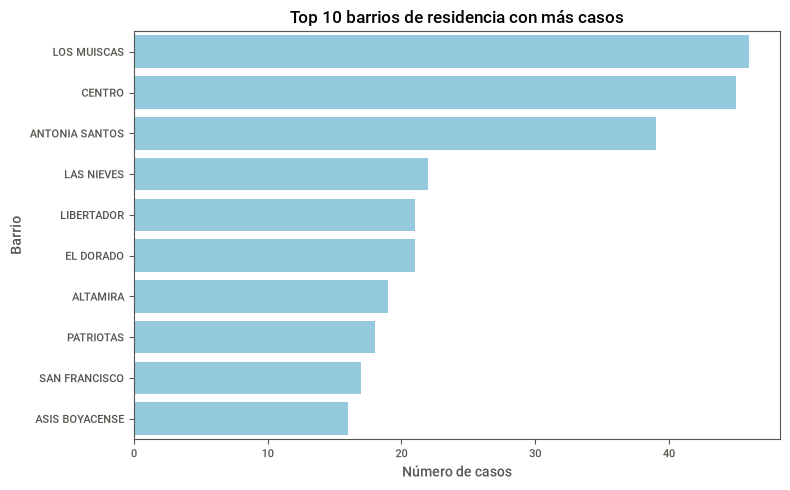

In [8]:
# Top 10 barrios con más casos registrados
top_barrios = datos['barrio_de_residencia'].value_counts().head(10)
print("Top 10 barrios de residencia:")
display(top_barrios)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_barrios.values, y=top_barrios.index, color="skyblue")
plt.xlabel("Número de casos")
plt.ylabel("Barrio")
plt.title("Top 10 barrios de residencia con más casos")
plt.tight_layout()
plt.show()

El barrio LOS MUISCAS concentra el mayor número de casos (46), seguido de CENTRO (45) y ANTONIA SANTOS (39). 

#### Medidas de variabilidad

In [9]:
df_numeric = datos[numeric_columns]

# Cálculo de medidas de variabilidad
variability_df = pd.DataFrame({
    "Coeficiente de variación": (df_numeric.std() / df_numeric.mean())*100,
    "Varianza": df_numeric.var(),
    "Desviación estándar": df_numeric.std(),
    "Rango": df_numeric.max() - df_numeric.min()
})

# Ordenando por las de mayor variabilidad
variability_df = variability_df.sort_values(by="Coeficiente de variación", ascending=False)

# Muestra los resultados
print("\n### Medidas de variabilidad ###\n")
print(variability_df.to_string())


### Medidas de variabilidad ###

                        Coeficiente de variación  Varianza  Desviación estándar  Rango
numero_de_intentos                     90.778070  1.263788             1.124183      4
estrato_socioeconomico                 38.066901  0.929754             0.964237      4


El numero_de_intentos presenta mayor variabilidad relativa (CV≈90.8%), es decir, una dispersión relativa mucho más alta frente a su propia media.

#### Medidas de forma

In [10]:
# Asimetría y Kurtosis
shape_metrics_df = pd.DataFrame({
    "Skewness": df_numeric.skew(),
    "Kurtosis": df_numeric.kurtosis()
})

# Ordenando por las más asimétricas
shape_metrics_df = shape_metrics_df.sort_values(by="Skewness", key=abs, ascending=False)

# Muestra los resultados
print("\n### Medidas de forma ###\n")
print(shape_metrics_df.to_string())


### Medidas de forma ###

                        Skewness  Kurtosis
numero_de_intentos      0.961662  0.267283
estrato_socioeconomico  0.119760 -0.260147


El numero_de_intentos muestra asimetría positiva moderada (0.96): la mayoría de los casos tiene pocos intentos y una cola de casos con varios intentos alarga la distribución a la derecha. Ambas variables tienen kurtosis negativa (distribución más achatada que la normal), sin colas pesadas ni valores extremos infrecuentes.

#### Medidas de posición

In [11]:
# Definición de los percentiles
percentile_values = {
    "Terciles": [33, 66],
    "Cuartiles": [25, 50, 75],
    "Quintiles": [20, 40, 60, 80]
}

# Cálculo de los percentiles
percentile_results = {}
for key, values in percentile_values.items():
    percentiles = {f"{p}%": np.percentile(df_numeric, p, axis=0) for p in values}
    percentile_results[key] = pd.DataFrame(percentiles, index=df_numeric.columns)

for key, df_perc in percentile_results.items():
    print(f"\n### {key} ###\n")
    print(df_perc.to_string())


### Terciles ###

                        33%  66%
estrato_socioeconomico  2.0  3.0
numero_de_intentos      1.0  1.0

### Cuartiles ###

                        25%  50%  75%
estrato_socioeconomico  2.0  3.0  3.0
numero_de_intentos      0.0  1.0  2.0

### Quintiles ###

                        20%  40%  60%  80%
estrato_socioeconomico  2.0  2.0  3.0  3.0
numero_de_intentos      0.0  1.0  1.0  2.0


La mediana de numero_de_intentos es 1 en todos los cortes (terciles, cuartiles, quintiles), y solo el 25% superior de los casos llega a 2 o más intentos lo que nos confirma que la mayoría de las personas registra al menos un intento y estrato_socioeconomico se concentra entre 2 y 3 en todos los cortes.

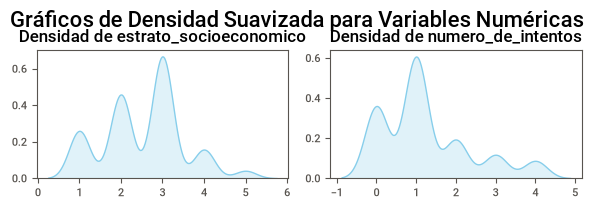

In [12]:
n_cols = len(numeric_columns)
n_rows = int(np.ceil(len(numeric_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.kdeplot(datos[col], ax=axes[i], fill=True, color='skyblue')
    axes[i].set_title(f'Densidad de {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.suptitle('Gráficos de Densidad Suavizada para Variables Numéricas', y=1.02, fontsize=16)
plt.show()

Las curvas de densidad confirman lo anterior de forma visual: numero_de_intentos se concentra en 0-1 con una cola larga hacia la derecha, mientras estrato_socioeconomico tiene una forma más simétrica centrada en 2-3.

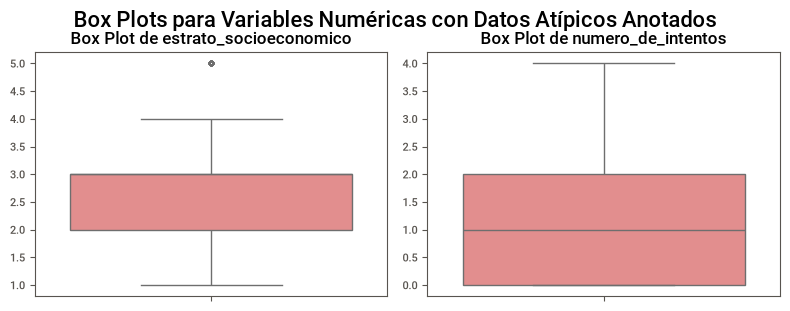

In [13]:
# Box plots para variables numericas
n_cols = len(numeric_columns)
n_rows = int(np.ceil(len(numeric_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(y=datos[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Box Plot de {col}')
    axes[i].set_ylabel('')


  
    if col == 'numero_de_intentos':
        Q1 = datos[col].quantile(0.25)
        Q3 = datos[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

     
        outliers = datos[(datos[col] < lower_bound) | (datos[col] > upper_bound)]


        for idx, outlier in outliers.iterrows():
            edad_rango = outlier['edad_rango']
            outlier_value = outlier[col]
            axes[i].text(0.1, outlier_value, edad_rango,
                         horizontalalignment='left', size='small', color='red', weight='semibold')
            axes[i].plot(0, outlier_value, 'o', color='blue', markersize=5)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.suptitle('Box Plots para Variables Numéricas con Datos Atípicos Anotados', y=1.02, fontsize=16)
plt.show()

No se detecta ningún outlier en numero_de_intentos (Q1=0, Q3=2, límite superior=5, y el máximo real es 4).

#### Medidas y gráficas descriptivas multivariadas

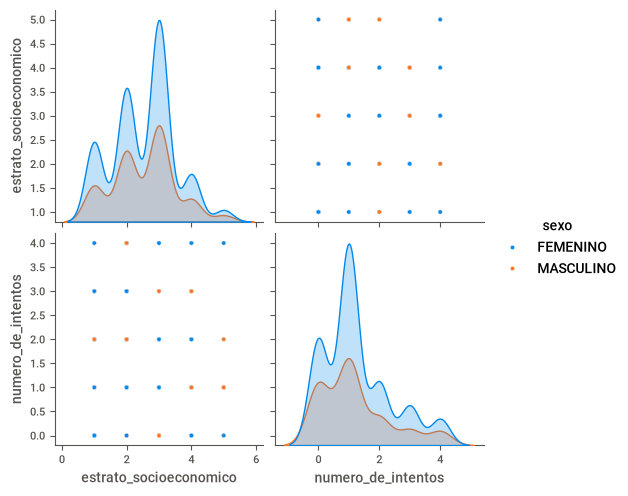

In [14]:
#Gráfico exploratorio por pares de variables, coloreado por sexo
sns.pairplot(datos[numeric_columns + ['sexo']], hue='sexo')

,estrato_socioeconomico,numero_de_intentos
estrato_socioeconomico,1.000000,0.052013
numero_de_intentos,0.052013,1.000000


<Axes: >

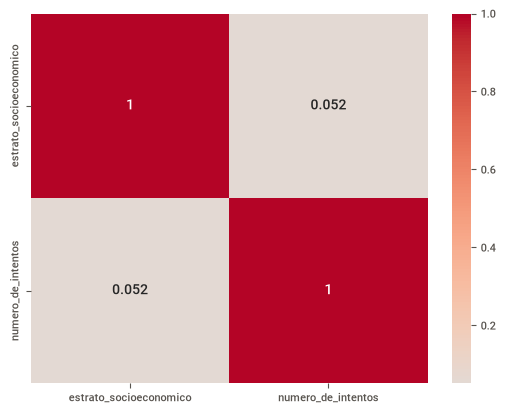

In [15]:
#La matriz de correlaciones
correlation_matrix = df_numeric.corr()
display(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)

La correlación entre estrato_socioeconomico y numero_de_intentos es prácticamente nula (0.05): el número de intentos no depende linealmente del estrato socioeconómico en estos datos.

#### Correlación entre factores de riesgo (variables binarias)

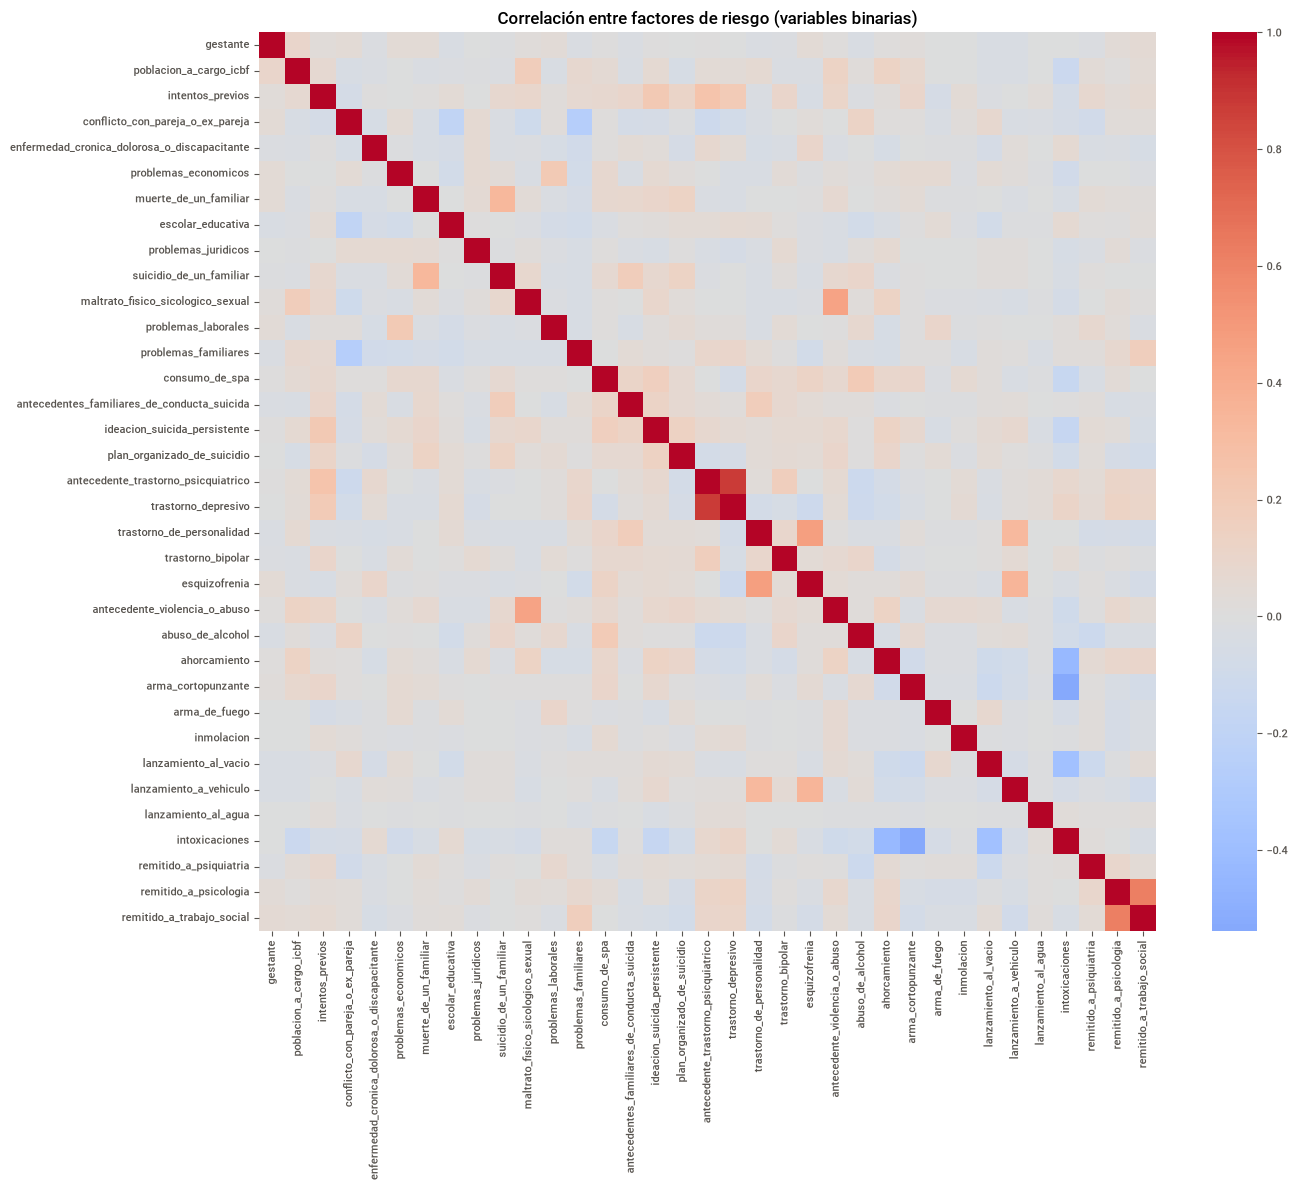

In [16]:
# Matriz de correlación entre las variables binarias (co-ocurrencia de factores de riesgo)
binary_corr = datos[binary_columns].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(binary_corr, cmap="coolwarm", center=0)  
plt.title("Correlación entre factores de riesgo (variables binarias)")
plt.tight_layout()
plt.show()

Encontramos que algunos factores suelen estar muy correlacionados. Por ejemplo, los antecedentes de trastornos psiquiátricos están muy relacionados con los trastornos depresivos, y las remisiones a psicología suelen estar relacionadas con las remisiones a trabajo social.

En cuanto a los métodos utilizados, como ahorcamiento, arma cortopunzante o intoxicación, las relaciones negativas no significan necesariamente que uno disminuya al otro. Se deben a que, normalmente, cada caso tiene registrado un solo método. Por eso, podria ser mejor agruparlos en una sola variable llamada “método del intento”.

#### Factores de riesgo más asociados a numero_de_intentos

In [17]:
# Correlación punto-biserial entre cada factor de riesgo y el número de intentos
corr_con_intentos = datos[binary_columns].corrwith(datos['numero_de_intentos']).sort_values(ascending=False)
print("Correlación de cada factor de riesgo con numero_de_intentos:")
display(corr_con_intentos)

Correlación de cada factor de riesgo con numero_de_intentos:


intentos_previos                                0.664684
ideacion_suicida_persistente                    0.233077
antecedente_trastorno_psicquiatrico             0.151326
suicidio_de_un_familiar                         0.149422
antecedentes_familiares_de_conducta_suicida     0.136375
arma_cortopunzante                              0.126605
plan_organizado_de_suicidio                     0.124229
trastorno_bipolar                               0.100543
lanzamiento_a_vehiculo                          0.098490
trastorno_depresivo                             0.095392
consumo_de_spa                                  0.091671
maltrato_fisico_sicologico_sexual               0.084379
antecedente_violencia_o_abuso                   0.081078
trastorno_de_personalidad                       0.068499
muerte_de_un_familiar                           0.051920
problemas_economicos                            0.041955
poblacion_a_cargo_icbf                          0.041357
problemas_laborales            

Los Intentos_previos es el factor más asociado a numero_de_intentos (0.66), entre los factores de riesgo encontramos que la ideacion_suicida_persistente (0.23) y antecedente_trastorno_psicquiatrico (0.15) son los más relevantes; la mayoría de las demás variables tiene una asociación lineal débil.

#### Comparación de numero_de_intentos por grupos demográficos

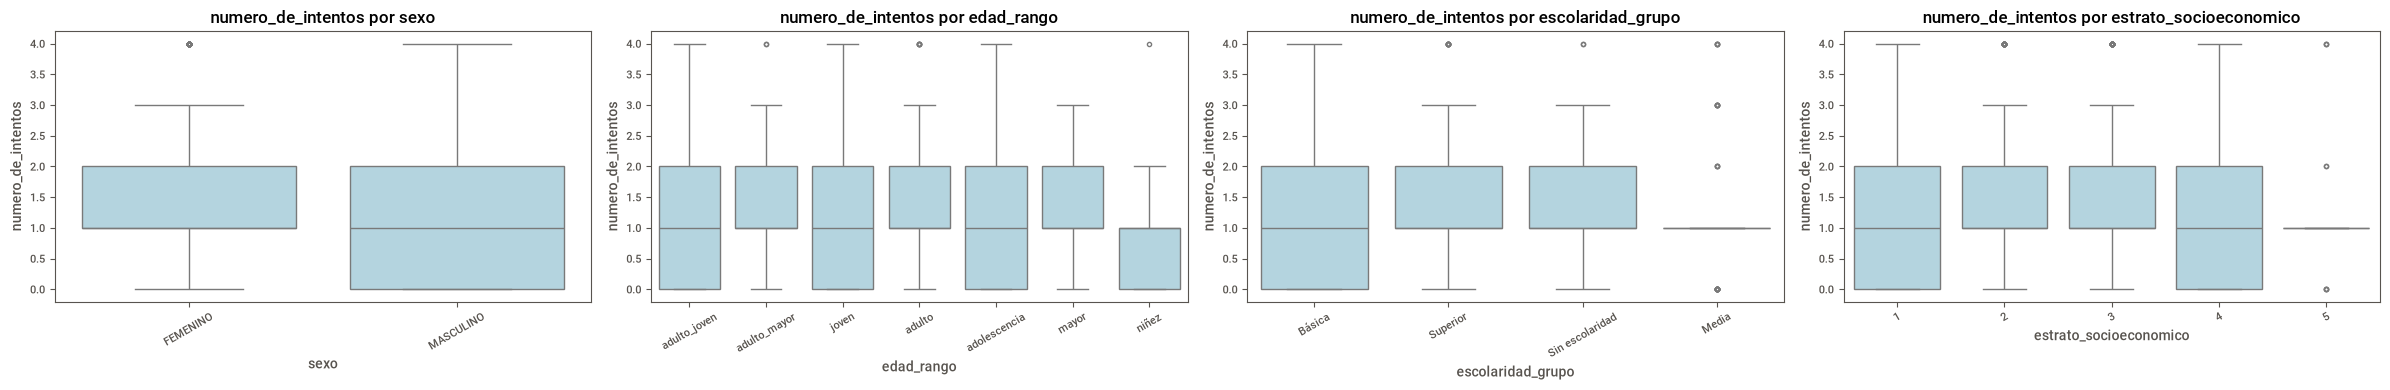


numero_de_intentos por sexo:
               mean  median       std
sexo                                 
FEMENINO   1.262760     1.0  1.108231
MASCULINO  1.193772     1.0  1.153420

numero_de_intentos por edad_rango:
                  mean  median       std
edad_rango                              
mayor         1.400000     1.0  1.074968
adulto        1.366197     1.0  1.198087
adulto_mayor  1.333333     1.0  1.095445
adulto_joven  1.277419     1.0  1.181763
joven         1.231250     1.0  1.101278
adolescencia  1.169014     1.0  1.102988
niñez         1.000000     1.0  1.154701

numero_de_intentos por escolaridad_grupo:
                       mean  median       std
escolaridad_grupo                            
Media              1.292308     1.0  1.155464
Sin escolaridad    1.285714     1.0  1.088425
Superior           1.251366     1.0  1.054653
Básica             1.223485     1.0  1.148903

numero_de_intentos por estrato_socioeconomico:
                            mean  median      

In [18]:
# Comparamos numero_de_intentos entre grupos demográficos
grupos_demograficos = ['sexo', 'edad_rango', 'escolaridad_grupo', 'estrato_socioeconomico']

fig, axes = plt.subplots(1, len(grupos_demograficos), figsize=(6 * len(grupos_demograficos), 4))

for i, grupo in enumerate(grupos_demograficos):
    sns.boxplot(x=grupo, y='numero_de_intentos', data=datos, ax=axes[i], color='lightblue')
    axes[i].set_title(f'numero_de_intentos por {grupo}')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

for grupo in grupos_demograficos:
    print(f"\nnumero_de_intentos por {grupo}:")
    print(datos.groupby(grupo)['numero_de_intentos'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False))

Las diferencias son minimas en cuanto al genero, el genero FEMENINO tiene un poco mas de intentos que MASCULINO (1.26 vs 1.19), y hay una tendencia a mayor numero de intentos en los grupos de mayor edad (adulto, adulto_mayor, mayor rondan 1.33-1.40) frente a los más jóvenes (adolescencia 1.17). Sin embargo como mayor y niñez tienen muy pocos casos (10 y 13)  sus promedios extremos deben analizarse con mas cautela. Por escolaridad no hay una diferencia clara entre grupos (todos entre 1.22 y 1.29).

#### Incidencia de factores de riesgo por sexo y edad_rango

In [19]:
# Incidencia (%) de los factores de riesgo binarios segmentada por sexo y por edad_rango
orden_binarias = datos[binary_columns].mean().sort_values(ascending=False).index

incidencia_por_sexo = (datos.groupby('sexo')[binary_columns].mean() * 100).T.loc[orden_binarias]
incidencia_por_edad = (datos.groupby('edad_rango')[binary_columns].mean() * 100).T.loc[orden_binarias]

print("Incidencia (%) de factores de riesgo por sexo (top 10):")
display(incidencia_por_sexo.head(10))

print("\nIncidencia  (%) de factores de riesgo por rango de edad (top 10):")
display(incidencia_por_edad.head(10))

Incidencia (%) de factores de riesgo por sexo (top 10):


sexo,FEMENINO,MASCULINO
remitido_a_psiquiatria,91.304348,91.003460
remitido_a_psicologia,87.145558,87.197232
remitido_a_trabajo_social,74.669187,75.086505
intoxicaciones,67.296786,51.903114
intentos_previos,56.710775,51.557093
antecedente_trastorno_psicquiatrico,54.631380,51.903114
trastorno_depresivo,49.338374,44.982699
problemas_familiares,46.124764,36.332180
ideacion_suicida_persistente,37.807183,42.906574
conflicto_con_pareja_o_ex_pareja,31.568998,40.830450



Incidencia  (%) de factores de riesgo por rango de edad (top 10):


edad_rango,adolescencia,adulto,adulto_joven,adulto_mayor,joven,mayor,niñez
remitido_a_psiquiatria,91.079812,90.140845,89.032258,86.111111,93.1250,90.0,92.307692
remitido_a_psicologia,89.201878,88.732394,85.161290,94.444444,85.6250,70.0,100.000000
remitido_a_trabajo_social,79.342723,71.830986,72.903226,72.222222,72.8125,80.0,92.307692
intoxicaciones,65.258216,56.338028,61.935484,66.666667,63.1250,40.0,7.692308
intentos_previos,51.173709,60.563380,57.419355,55.555556,54.3750,60.0,61.538462
antecedente_trastorno_psicquiatrico,47.417840,64.788732,54.838710,41.666667,57.1875,40.0,38.461538
trastorno_depresivo,44.600939,53.521127,52.903226,30.555556,49.3750,30.0,30.769231
problemas_familiares,54.929577,29.577465,34.193548,33.333333,40.9375,50.0,76.923077
ideacion_suicida_persistente,36.150235,46.478873,42.580645,22.222222,42.1875,10.0,30.769231
conflicto_con_pareja_o_ex_pareja,17.370892,47.887324,54.838710,50.000000,34.0625,20.0,0.000000


Al comparar los resultados por sexo, se observan algunas diferencias. Las intoxicaciones son más frecuentes en mujeres que en hombres (67,3% frente a 51,9%). También se presentan más problemas familiares en mujeres (46,1%) que en hombres (36,3%). En los demás factores analizados, como las remisiones a psiquiatría y psicología, las diferencias entre hombres y mujeres son pequeñas.

Al comparar los grupos de edad, las diferencias son más evidentes. Los antecedentes de trastornos psiquiátricos aparecen con mayor frecuencia en los adultos (64,8%) que en los adolescentes (47,4%). En cambio, los problemas familiares tienen una mayor presencia en niños y adolescentes (77% y 55%, respectivamente) que en los adultos (30%). Esto sugiere que, en las edades más tempranas, las situaciones relacionadas con el entorno familiar tienen un mayor peso.


#### Analisis principal metodo de suicidio



Como identificamos en la sección de correlación entre binarias, las columnas de método (ahorcamiento, arma_cortopunzante, arma_de_fuego, inmolacion, lanzamiento_al_vacio, lanzamiento_a_vehiculo, lanzamiento_al_agua, intoxicaciones) describen en realidad una sola decisión por caso. Construimos una nueva variables `metodo_principal` a partir de ellas para analizarlas como una única variable categórica.

In [20]:
# Construimos una única variable categórica "metodo_principal" a partir de las columnas de método
columnas_metodo = ['ahorcamiento', 'arma_cortopunzante', 'arma_de_fuego', 'inmolacion',
                    'lanzamiento_al_vacio', 'lanzamiento_a_vehiculo', 'lanzamiento_al_agua',
                    'intoxicaciones']

def obtener_metodo(row):
    metodos = [col for col in columnas_metodo if row[col] == 1]
    if len(metodos) == 0:
        return 'no especificado'
    if len(metodos) > 1:
        return 'multiple'
    return metodos[0]

datos['metodo_principal'] = datos[columnas_metodo].apply(obtener_metodo, axis=1)

print("Distribución de metodo_principal:")
display(datos['metodo_principal'].value_counts())

Distribución de metodo_principal:


metodo_principal
intoxicaciones            452
arma_cortopunzante        121
ahorcamiento               79
multiple                   76
lanzamiento_al_vacio       61
lanzamiento_a_vehiculo     24
no especificado             3
arma_de_fuego               1
inmolacion                  1
Name: count, dtype: int64

Intoxicaciones es el método más frecuente (452 casos, 55%), seguido de arma_cortopunzante (121) y ahorcamiento (79). Sin embargo no todos los casos tienen un único método — 76 registros (9.3%) tienen más de un método marcado en 1 simultáneamente y 3 no tienen ninguno marcado.

#### Análisis temporal

Medidas de tendencia central - días de retraso en la notificación:


mean        4.257946
median      0.000000
std        15.219189
min         0.000000
max       228.000000
Name: dias_retraso_notificacion, dtype: float64

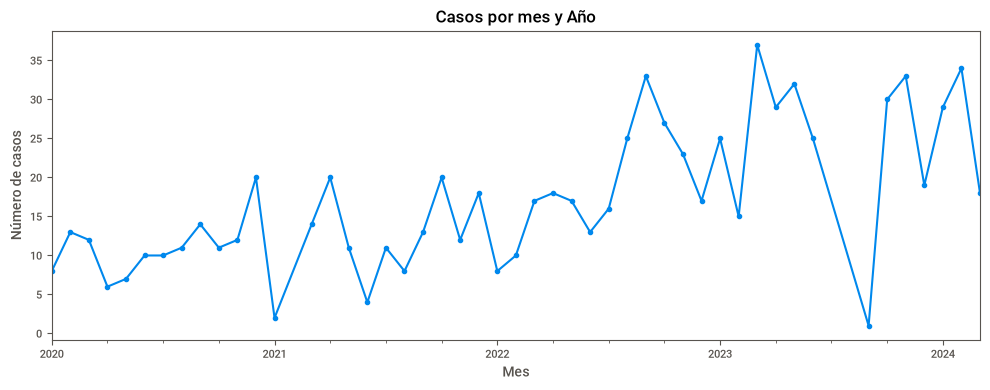

In [21]:
# Conversión de las fechas y cálculo del retraso entre el hecho y la notificación
datos['fecha_del_hecho'] = pd.to_datetime(datos['fecha_del_hecho'])
datos['fecha_de_notificacion_del_evento'] = pd.to_datetime(datos['fecha_de_notificacion_del_evento'])
datos['dias_retraso_notificacion'] = (datos['fecha_de_notificacion_del_evento'] - datos['fecha_del_hecho']).dt.days

print("Medidas de tendencia central - días de retraso en la notificación:")
display(datos['dias_retraso_notificacion'].agg(["mean", "median", "std", "min", "max"]))

# Casos por mes
casos_por_mes = datos['fecha_del_hecho'].dt.to_period("M").value_counts().sort_index()
casos_por_mes.plot(kind="line", figsize=(10, 4), marker="o")
plt.title("Casos por mes y Año")
plt.xlabel("Mes")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.show()

Podemos identificar que la mayoría de los casos (431 de 818, ~53%) se notifica el mismo día del hecho, por eso la mediana es 0, mientras que el promedio (4.3 días) está inflado por una cola de 40 casos con más de 30 días de retraso (hasta 228 días).

#### Casos por año

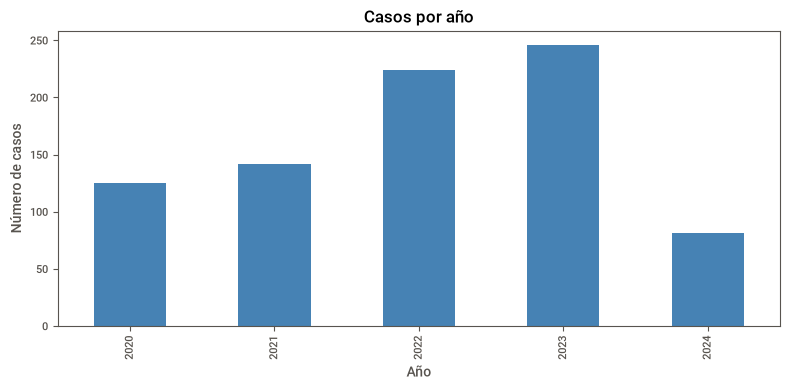

id_ano
2020    125
2021    142
2022    224
2023    246
2024     81
Name: count, dtype: int64


In [22]:
# Casos por año
casos_por_ano = datos['id_ano'].value_counts().sort_index()
casos_por_ano.plot(kind='bar', figsize=(8, 4), color='steelblue')
plt.title('Casos por año')
plt.xlabel('Año')
plt.ylabel('Número de casos')
plt.tight_layout()
plt.show()

print(casos_por_ano)

Los casos crecen de forma sostenida entre 2020 y 2023 (125 → 142 → 224 → 246), casi duplicándose en tres años. En 2024 observamos un descenso a  casos sin embargo intuimos que los datos de ese año pueden estar incompletos ya que el dataset reportado solo registra informacion hasta marzo de 2024

#### Hallazgos generales



- **Perfil general**: mujer, joven, residente en la CABECERA MUNICIPAL (barrio LOS MUISCAS o CENTRO), régimen CONTRIBUTIVO, SOLTERO(A), con escolaridad Básica, y un solo intento registrado (numero_de_intentos ≈ 1.24 en promedio).
- **Factores de riesgo dominantes**: remisión a psiquiatría (91%) y psicología (87%) principalmente; el 55% reporta intentos previos. Los antecedentes de trastorno psiquiátrico están fuertemente asociados a trastorno depresivo (correlación 0.88), y las remisiones a psicología a las de trabajo social (0.62).
- **Diferencias demográficas moderadas**: las mujeres presentan más intoxicaciones (67% vs 52%) y problemas familiares (46% vs 36%) que los hombres; los adultos tienen más antecedente de trastorno psiquiátrico que los adolescentes, mientras que en niñez y adolescencia tienes más  peso los problemas familiares.
- **Método**: intoxicaciones es el método más usado (55% de los casos); las 8 columnas de método originales se resumen mejor en la variable derivada `metodo_principal`.
- **Tendencia**: los casos casi se duplicaron entre 2020 y 2023 (125 → 246); la notificación es mayormente el mismo día (53%), salvo una cola de 40 casos con más de 30 días de retraso.
